In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from phd_helpers.experiments import parse_tekscan, force_per_frame, get_frame_at_F, get_instron_data

# 20260227

# Check instron and tekscan agreement - after calibration
Do compression test of bone samples up to fixed force value (don't return at end and do tekscan recording)  
Then compare force values at final frame / tick of tekcsan / instron data

In [ ]:
tests = np.arange(1, 4)
for test in tests:
    print(f'TEST {test}:')

    date = "20260227"
    tek_file = f'{date}/test-tekscan/test{test}.asm'
    header, (s1, s2, s3, s4) = parse_tekscan(tek_file)

    test_name = 'CalibrationTest'
    instron_file = f'{date}/test-instron/{test_name}.is_comp_Exports/{test_name}_{test}.csv'
    instron_data = get_instron_data(instron_file)

    # force at frame
    F_instron = (instron_data['force']*1e3)
    F_tek = force_per_frame(s1, header)

    print(f'\tInstron force: {F_instron.iloc[-1]:.2f} N')
    print(f'\tTekscan force: {F_tek.max():.2f} N') 
#GET FRAME AT MAX FORCE NOT LAST FRAME FOR TEKSCAN (UNLESS CAN GUARANTEE TEKSCAN WAS STOPPED AT SAME TIME AS INSTRON - DIFFICULT...)

TEST 1:
	Instron force: 50.00 N
	Tekscan force: 43.36 N
TEST 2:
	Instron force: 50.10 N
	Tekscan force: 46.27 N
TEST 3:
	Instron force: 50.00 N
	Tekscan force: 20.66 N


In [20]:
20.66 * 2.35

48.551

# External 10 point cubic calibration (https://pubmed.ncbi.nlm.nih.gov/19154074/)

Least squares fit of:  
$$
F_i = a_1 R_i^3 + a_2 R_i^2 + a_3 R_i + a_4
$$

Where $F_i$ is the applied instron Force at calibration step $i$, $R_i$ is the sum of raw sensel values at that step, and $a_k$ are the fitted coefficients

 - Calibrate over expected pressure range (not force range)
 - Probably best to apply each of the 10 loads for a short period of time, then average raw values over several frames, to reduce influence of any noise?
  
 - Mapping force per sensel based on this fit assumes uniform sensel sensitivity (tekscans calibration also assumes this, i think). Would need to do an equilibrium / normalisation step to account for this, but that requires being able to confidently apply a uniform pressure over the sensor, difficult...
 - Doing external fit also allows me to see / quantify the fit error

In [74]:
def fit_cubic(forces, raw_frames):
    """
    forces: (N,)\n
    raw_frames: (N,i,j) array OR list of (i,j) arrays\n

    returns: dict with coeffs, RMSE, R^2, F_pred
    """
    F = np.asarray(forces, dtype=float).reshape(-1) # F_i
    raw = np.asarray(raw_frames, dtype=float)

    # sum of raw sensel values for each calibration step
    R = raw.sum(axis=(1, 2)) # R_i
    # Least squares fit
    A = np.column_stack([R**3, R**2, R, np.ones_like(R)])
    coeffs, residuals, rank, svals = np.linalg.lstsq(A, F)
    a3, a2, a1, a0 = coeffs

    # Predictions and error
    F_pred = A @ coeffs
    rmse = float(np.sqrt(np.mean((F - F_pred) ** 2)))
    ss_res = float(np.sum((F - F_pred) ** 2))
    ss_tot = float(np.sum((F - np.mean(F)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

    return {
        "coeffs": (a3, a2, a1, a0),
        "rmse": rmse,
        "r2": r2,
        "R": R, # sum of raw sensel values for each calibration step
        "F_pred": F_pred, # prediction
    }

#### Testing

In [40]:
# test

forces = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

N, i_cells, j_cells = 10, 11, 11 
rng = np.random.default_rng(0)
raw_frames = rng.random((N, i_cells, j_cells))

result = fit_cubic(forces, raw_frames)
a3, a2, a1, a0 = result['coeffs']
print("Cubic coefficients for F = a3*R^3 + a2*R^2 + a1*R + a0")
print(f"a3 = {a3:.2e}")
print(f"a2 = {a2:.2e}")
print(f"a1 = {a1:.2e}")
print(f"a0 = {a0:.2e}")
print(f"RMSE = {result['rmse']:.2g} (force units)")
print(f"R^2  = {result['r2']:.2g}")

Cubic coefficients for F = a3*R^3 + a2*R^2 + a1*R + a0
a3 = 2.90e+00
a2 = -5.42e+02
a1 = 3.38e+04
a0 = -6.99e+05
RMSE = 93 (force units)
R^2  = 0.58


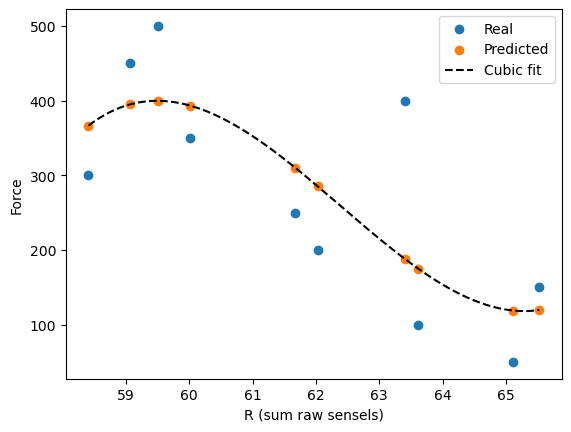

In [61]:
F = np.asarray(forces, float)
R = result['R']

a3, a2, a1, a0 = result['coeffs']
F_pred = a3*R**3 + a2*R**2 + a1*R + a0

r_grid = np.linspace(R.min(), R.max(), 300)
f_grid = a3*r_grid**3 + a2*r_grid**2 + a1*r_grid + a0

fig, ax = plt.subplots()
ax.scatter(R, F, label="Real")
ax.scatter(R, F_pred, label="Predicted")
ax.plot(r_grid, f_grid, label="Cubic fit", color='black', linestyle='--')
ax.set_xlabel("R (sum raw sensels)")
ax.set_ylabel("Force")
ax.legend()
plt.show()

# 20260313

 - HIT MAX SENSEL RAW VALUE - 255
 - Reduce sensor sensitivity and aim for max raw value of around 200-230?
    - but doesn't hit 255 until ~50N so maybe what I have is fine? But the calibration is rubbish?

In [ ]:
date = '20260313'

# instron paths
ical_path = Path(f'{date}/cal-instron')
itest_path = Path(f'{date}/test-instron')

# tekscan paths
tcal_path = Path(f'{date}/cal-tekscan')
ttest_path = Path(f'{date}/test-tekscan')

# CALIBRATION #
# 0->400N at 1.0mm/min
ical_ramp400_1 = ical_path / '0-400N-test1-test3.is_comp_Exports/0-400N-test1.csv'
tcal_ramp400_1 = tcal_path / '0-400N-test1.asm'

# 0->400N at 0.2mm/min
ical_ramp400_3 = ical_path / '0-400N-test1-test3.is_comp_Exports/0-400N-test3.csv' 
tcal_ramp400_3 = tcal_path / '0-400N-test3.asm'

# TESTING #
# 0->50N at 1mm/min
itest_ramp50 = itest_path / '50N-75N.is_comp_Exports/50N-75N_1.csv'
ttest_ramp50 = ttest_path / '0-50N.asm'

# 0->75N at 1mm/min
itest_ramp75 = itest_path / '50N-75N.is_comp_Exports/50N-75N_2.csv'
ttest_ramp75 = ttest_path / '0-75N.asm'


### Calibration

In [4]:
def get_tekscan_frames(Fs, instron_path, tekscan_path, tekscan_sensor):
    """For a syncronised tekscan and instron test, 
    returns an array of tekscan frames corresponding to each given Force (F)\n
    shape(Fs, res_i, res_j)"""
    i_data = get_instron_data(instron_path)
    t_header, t_data = parse_tekscan(tekscan_path)
    t_data_s = t_data[tekscan_sensor-1] # date for chosen senosor

    frame_ids = [get_frame_at_F(F, i_data, t_header) for F in Fs]
    frames = [t_data_s[x] for x in frame_ids]
    return np.array(frames)

In [106]:
step = 5
cal_Fs = np.arange(0, 50+step, step)

# FIT CUBICS #
Rs_ramp400_1 = get_tekscan_frames(cal_Fs, ical_ramp400_1, tcal_ramp400_1, 1)
fit_ramp400_1 = fit_cubic(cal_Fs, Rs_ramp400_1)

Rs_ramp400_3 = get_tekscan_frames(cal_Fs, ical_ramp400_3, tcal_ramp400_3, 1)
fit_ramp400_3 = fit_cubic(cal_Fs, Rs_ramp400_3)

print('Max raw sensel value', Rs_ramp400_1.max())
print('Max raw sensel value', Rs_ramp400_3.max())

Max raw sensel value 223.0
Max raw sensel value 255.0


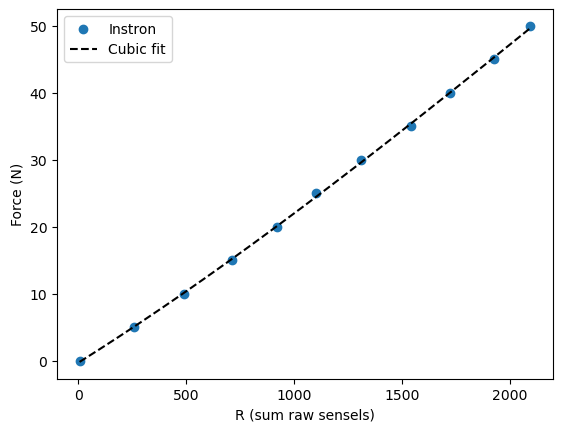

In [100]:
cali = fit_ramp400_1

R = cali['R']
a3, a2, a1, a0 = cali['coeffs']

F_pred = a3*R**3 + a2*R**2 + a1*R + a0
F = np.asarray(cal_Fs, float)


r_grid = np.linspace(R.min(), R.max(), 300)
f_grid = a3*r_grid**3 + a2*r_grid**2 + a1*r_grid + a0

fig, ax = plt.subplots()
ax.scatter(R, F, label="Instron")
#ax.scatter(R, F_pred, label="Predicted")
ax.plot(r_grid, f_grid, label="Cubic fit", color='black', linestyle='--')
ax.set_xlabel("R (sum raw sensels)")
ax.set_ylabel("Force (N)")
ax.legend()
plt.show()

### Testing

In [ ]:
def plot_results(F, F_tek):
    fig, ax = plt.subplots()
    ax.scatter(F, F, label="Instron")
    ax.scatter(F, F_tek, label="Tekscan")
    ax.set_xlabel("Instron Force (N)")
    ax.set_ylabel("Force (N)")
    ax.legend()
    ax.grid()
    plt.show()

def R2P_cubic(raw_frames, coeffs, sensor_area=1.6129):
    """
    Convert raw tekscan frames to pressure frames using cubic fit\n
    raw_frames: (N,i,j) array OR list of (i,j) arrays\n
    coeffs: (a3, a2, a1, a0)\n
    sensel area: (13.97/11)**2 mm^2
    """
    a3, a2, a1, a0 = coeffs
    raw = np.asarray(raw_frames, float)
    R = raw.sum(axis=(1, 2))
    F = a3*R**3 + a2*R**2 + a1*R + a0
    scale = (F / np.where(R == 0, 1.0, R)).reshape(F.shape[0], 1, 1) # avoid divide by zero but still outputs zeros cos raw=all 0s
    return (raw * scale) / sensor_area

def F2P(raw_frames, Forces, sensel_area=1.6129, i=11, j=11):
    """
    Convert raw tekscan frames to pressure frames by distributing force based on raw values\n
    raw_frames: (N,i,j) array OR list of (i,j) arrays\n
    sensel area: (13.97/11)**2 mm^2
    """

    raw = np.asarray(raw_frames, float).reshape(-1, i, j)
    R = raw.sum(axis=(1, 2))
    F = np.asarray(Forces, dtype=float).ravel()
    scale = (F / np.where(R == 0, 1.0, R)).reshape(F.shape[0], 1, 1) # avoid divide by zero but still outputs zeros cos raw=all 0s
    return (raw * scale) / sensel_area

In [86]:
test50_Fs = [10, 20, 30, 40, 50]
coeffs = fit_ramp400_1['coeffs']

Rs_ramp50 = get_tekscan_frames(test50_Fs, itest_ramp50, ttest_ramp50, 1)
Ps_ramp50 = R2P_cubic(Rs_ramp50, coeffs)
Fs_ramp50 = force_per_frame(Ps_ramp50)

test75_Fs = [10, 20, 30, 40, 50]

Rs_ramp75 = get_tekscan_frames(test75_Fs, itest_ramp75, ttest_ramp75, 1)
Ps_ramp75 = R2P_cubic(Rs_ramp75, coeffs)
Fs_ramp75 = force_per_frame(Ps_ramp75)

print('Max raw sensel value', Rs_ramp50.max())
print('Max raw sensel value', Rs_ramp75.max())

Max raw sensel value 239.0
Max raw sensel value 246.0


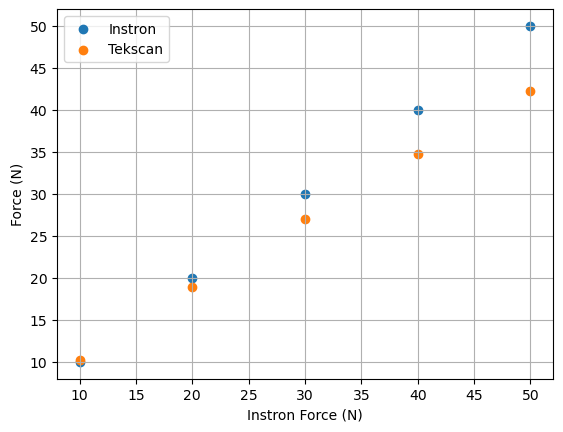

In [87]:
plot_results(test50_Fs, Fs_ramp50)

In [88]:
print("\nCALIBRATION")
print('Max raw sensel value', Rs_ramp400_1.max())
print('Max raw sensel value', Rs_ramp400_3.max())

print("\nTESTING")
print('Max raw sensel value', Rs_ramp50.max())
print('Max raw sensel value', Rs_ramp75.max())


CALIBRATION
Max raw sensel value 223.0
Max raw sensel value 255.0

TESTING
Max raw sensel value 239.0
Max raw sensel value 246.0


In [110]:
Ps_ramp50[-1].max()

np.float64(3.464530085126749)

In [111]:
F2P(Rs_ramp50, test50_Fs)[-1].max()

np.float64(4.100174221377773)

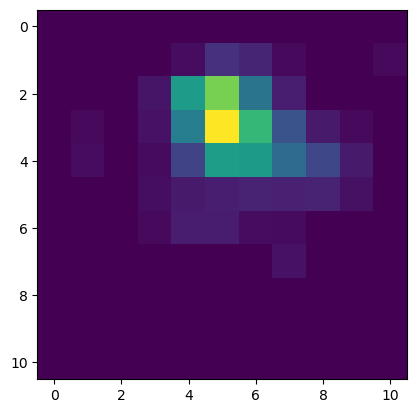

In [98]:
plt.imshow(Ps_ramp50[4][::-1])

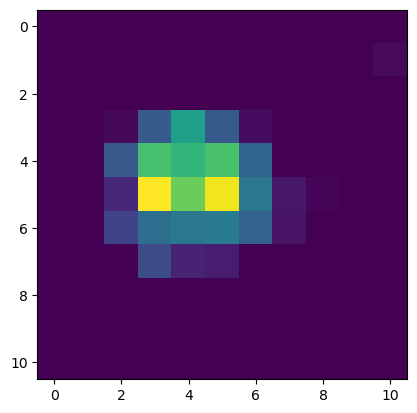

In [107]:
plt.imshow(Rs_ramp400_1[-1][::-1])

# 20260317

 - Found that calibration with the vero block works fine for the blocks, but when used with the tpm-mc1 gives a reading of 35N for 50N force.  
  
  
 - But if i-scan just distributes force evenly over the sensels then don't need to calibrate, can just do the same (cos all contact is within sensor area). 
    - Going to reverse engineer what tekscan does for calibration to check this is justified

In [14]:
def polyfit(x, y, degree, intercept=True):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    start = 0 if intercept else 1
    X = np.column_stack([x**k for k in range(start, degree + 1)])

    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef

def polyval(coef, x, intercept=True):
    x = np.asarray(x)
    start = 0 if intercept else 1
    yhat = np.zeros_like(x, dtype=float)
    for k, a in enumerate(coef, start=start):
        yhat += a * x**k
    return yhat

from scipy.optimize import curve_fit
def power_law(x, y):
    # model
    def _power_law(x, a, b):
        return a * x**b
    # fit
    (a, b), _ = curve_fit(_power_law, x, y)

    return a, b

In [6]:
date = '20260317'

# instron paths
cal_path = Path(f'{date}/cal-tekscan')
test_path = Path(f'{date}/test-tekscan')

test1_path = test_path / 'test1'
test2_path = test_path / 'test2'

## cal4 1-point linear fit

In [7]:
cal = 'cal4'

# calibration file
cal_file = cal_path / f'{cal}.cal'
# 10N raw frame
raw10 = parse_tekscan(cal_path / f'{cal}-10N-raw.asm', sensor=1)
R10 = raw10.sum()
# 10N mpa frame
mpa10 = parse_tekscan(cal_path / f'{cal}-10N-mpa.asm', sensor=1)

# Total force 10 N
F10 = 10

##### For calibration frame the force is distributed proportionally over the sensels


In [8]:
np.round(F2P(raw10, F10), 3) - mpa10

array([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]])

In [9]:
np.array_equal(np.round(F2P(raw10, F10), 3), mpa10)

True

#### For a 1-point fit the force is linearly distributed over the raw sensel values

In [148]:
# 1-point linear fit at 10N frame
c1 = polyfit(R10, F10, 1, intercept=False)
print(f'fit: {c1[0]:.5}')
print(f'tekscan: {10/320:.5}')


# check if tekscan results match fit
Fs = np.linspace(10, 50, 5, dtype=int)

for i, test in enumerate([test1_path, test2_path], start=1):
    print(f'\nTest {i}:')
    for F in Fs:
        
        raw = parse_tekscan(test / f'{F}N-raw.asm', sensor=1)
        R = raw.sum()
        mpa = parse_tekscan(test / f'{cal}-{F}N-mpa.asm', sensor=1)


        Fhat = c1*R
        print(f'Tekscan matches fit at {F}N', np.sum(np.round(F2P(raw, Fhat), 3) - mpa) == 0)

fit: 0.029412
tekscan: 0.03125

Test 1:
Tekscan matches fit at 10N False
Tekscan matches fit at 20N False
Tekscan matches fit at 30N False
Tekscan matches fit at 40N False
Tekscan matches fit at 50N False

Test 2:
Tekscan matches fit at 10N False
Tekscan matches fit at 20N False
Tekscan matches fit at 30N False
Tekscan matches fit at 40N False
Tekscan matches fit at 50N False


## cal6 2-point power law fit

In [11]:
cal = f'cal6'

# calibration file
cal_file = cal_path / f'{cal}.cal'
# 10N, 60N raw frames
raw10 = parse_tekscan(cal_path / f'{cal}-10N-raw.asm', sensor=1)
raw60 = parse_tekscan(cal_path / f'{cal}-60N-raw.asm', sensor=1)
R10, R60 = raw10.sum(), raw60.sum()
# 10N, 60N mpa frames
mpa10 = parse_tekscan(cal_path / f'{cal}-10N-mpa.asm', sensor=1)
mpa60 = parse_tekscan(cal_path / f'{cal}-60N-mpa.asm', sensor=1)

# Total force 10 N
F10, F60 = 10, 60
F10c = 4.448222 * 1.66312 # convert cal file CAL_FPC_1 to Newtons
print(F10c)

7.3979269726400005


#### Can't just distribute the calibrated force evenly over the raw sensel values?

In [13]:
np.round(F2P(raw10, F10), 3) - mpa10

array([[[ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
          0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.018,  0.   ,  0.018,  0.014,
          0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.021,  0.   ,  0.013,  0.   ,  0.   ,  0.   ,
          0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.009,  0.018,  0.   ,  0.   ,  0.   ,  0.   ,
          0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.023,  0.   ,  0.   ,  0.   ,  0.014,  0.018,
          0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.015,  0.018,  0.   ,  0.   ,  0.013,  0.02 ,
          0.013,  0.013,  0.   ],
        [ 0.   ,  0.015,  0.018,  0.014,  0.013,  0.   ,  0.   ,  0.022,
          0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.021,  0.021,  0.   ,  0.013,  0.   ,  0.02 ,
          0.016,  0.02 ,  0.   ],
        [ 0.   ,  0.017, -0.127, -0.046,  0.017,  0.015,  0.013,  0.   ,
          0.018,  0.01 ,  0.   ],
        [ 0.   ,  0.   , -0.231, -0.0

## cal5 2-point power law fit

In [75]:
cal = f'cal5'

# calibration file
cal_file = cal_path / f'{cal}.cal'
# 10N, 60N raw frames
raw10 = parse_tekscan(cal_path / f'{cal}-10N-raw.asm', sensor=1)
raw60 = parse_tekscan(cal_path / f'{cal}-60N-raw.asm', sensor=1)
R10, R60 = raw10.sum(), raw60.sum()
# FORGOT TO SAVE CALIBRATION FRAMES AFTER CALIBRATING - but doesn't matter cos have test1 and test2 results

# Total force 10 N
F10, F60 = 10, 60

In [77]:
raw60

array([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.],
        [  0.,   0.,   0.,   0.,  14.,  20.,  36.,  46.,  11.,   0.,
           0.],
        [  0.,   0.,  58.,  23.,  25.,  24.,  47.,  29.,  21.,   0.,
           0.],
        [  0.,   6.,  88.,  40.,   4.,   8.,   7.,  13.,  10.,   9.,
           0.],
        [  0.,  13.,  55.,  10.,   8.,   0.,   6.,  10.,   0.,   9.,
           0.],
        [  0.,  14.,  26.,  24.,   0.,   0.,   5.,  11.,   7.,  14.,
           0.],
        [  0.,  26.,  28.,  25.,   5.,   0.,  10.,  13.,  18.,   9.,
           0.],
        [  0.,  20.,  41.,  35.,   6.,  17.,  11.,  34.,  48.,  42.,
           0.],
        [  0.,  23., 118.,  98.,  39.,  41.,  27.,  28.,  50.,  81.,
           0.],
        [  0.,   0., 132.,  80.,  33.,  55.,  21.,  20.,   9.,   0.,
           0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.]]])

#### using cal5 calibration file a(SCALE FACTOR) and b(EXPONENT) to figure out what's going on

they fit in PSI and apply the fit per sensel

In [97]:
cal = f'cal5'


# 2-point power law fit at 10N and 60N frames
a, b = 2.36625, 1.03604

# check if tekscan results match fit
Fs = np.linspace(10, 50, 5, dtype=int)

for i, test in enumerate([test1_path, test2_path], start=1):
    print(f'\nTest {i}:')
    for F in Fs:
        
        raw = parse_tekscan(test / f'{F}N-raw.asm', sensor=1)
        R = raw.sum()
        mpa = parse_tekscan(test / f'{cal}-{F}N-mpa.asm', sensor=1)


        psi_pred = (a*raw**b) 
        mpa_pred = np.round(psi_pred * 0.006894757, 3) # conversion of PSI to MPa - 0.006894757
        max_diff = np.max(np.abs(mpa_pred - mpa))
        print(f'Tekscan matches fit at {F}N', max_diff == 0)


Test 1:
Tekscan matches fit at 10N True
Tekscan matches fit at 20N True
Tekscan matches fit at 30N True
Tekscan matches fit at 40N True
Tekscan matches fit at 50N True

Test 2:
Tekscan matches fit at 10N True
Tekscan matches fit at 20N True
Tekscan matches fit at 30N True
Tekscan matches fit at 40N True
Tekscan matches fit at 50N True


a: 2.36625 
b: 1.03604


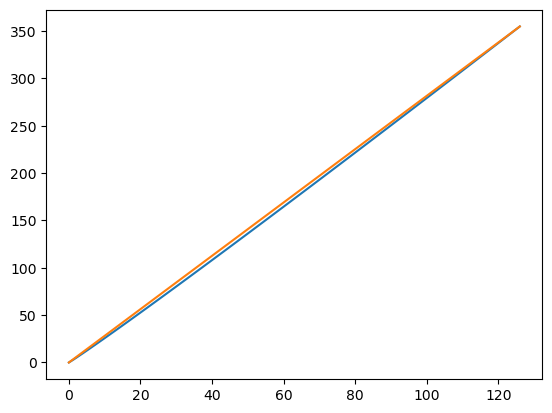

In [98]:
x = np.linspace(0, raw.max(), 100)
y = a*x**b
plt.plot(x, y)

y = (y.max()/x.max()) * x
plt.plot(x, y)

print(f'a: {a:.5f}', f'\nb: {b:.5f}')

#### getting a and b (this paper has nice description of tekscan method: https://pmc.ncbi.nlm.nih.gov/articles/PMC9571954/)

In [ ]:
def signif(x, p):
    """round to specific number of significant figures (from polars github discussion)"""
    x = np.asarray(x)
    x_positive = np.where(np.isfinite(x) & (x != 0), np.abs(x), 10**(p-1))
    mags = 10 ** (p - 1 - np.floor(np.log10(x_positive)))
    return np.round(x * mags) / mags

def N2FP(FN):
    """convert force from Newtions to Force Pounds like tescan does"""
    FP2N = 4.448222 # Force pounds * FP2N = Newtons
    return signif(FN / FP2N, 6)

In [ ]:
FP2N = 4.448222 # Force pounds * FP2N = Newtons
A = 0.55*0.55 # sensor area (square inch)
As = A / 121 # per sensel area 

In [137]:
F1 = N2FP(10)
F2 = N2FP(60)

from scipy.optimize import brentq

A = 0.0025  # sensel area (in^2)

x1 = raw10[raw10>0]
x2 = raw60[raw60>0]

def f(b):
    return (x2**b).sum() / (x1**b).sum() - round(F2/F1, 5)

b = brentq(f, 0, 10)
a = F1 / (A * (x1**b).sum())

print(f'a: {a:.5f}', '\tTekscan:', 2.36625)
print(f'b: {b:.5f}', '\tTekscan:', 1.03604)

a: 2.35885 	Tekscan: 2.36625
b: 1.03688 	Tekscan: 1.03604


In [138]:
round(F2/F1, 5)

np.float64(5.99998)

In [ ]:
# using what this paper says tekscans method is https://pmc.ncbi.nlm.nih.gov/articles/PMC9571954/

from scipy.optimize import minimize_scalar

# raw1, raw2 are calibration patch arrays
# F1, F2 are known calibration loads in Tekscan's fitting units

x1 = raw10[raw10>0]
x2 = raw60[raw60>0]

Fs = np.array([F1, F2])

def S(b):
    return np.array([(x1**b).sum(), (x2**b).sum()])

def A_of_b(b):
    s = S(b)
    return np.dot(Fs, s) / np.dot(s, s)

def J_of_b(b):
    s = S(b)
    A = A_of_b(b)
    err = A * s - Fs
    return np.dot(err, err)

res = minimize_scalar(J_of_b, bounds=(-10, 10), method="bounded")
b = res.x
a  = A_of_b(b) / A

print(f'a: {a:.5f}', '\tTekscan:', 2.36625)
print(f'b: {b:.5f}', '\tTekscan:', 1.03604)

a: 2.35884 	Tekscan: 2.36625
b: 1.03688 	Tekscan: 1.03604


a: 2.35884 
b: 1.03688


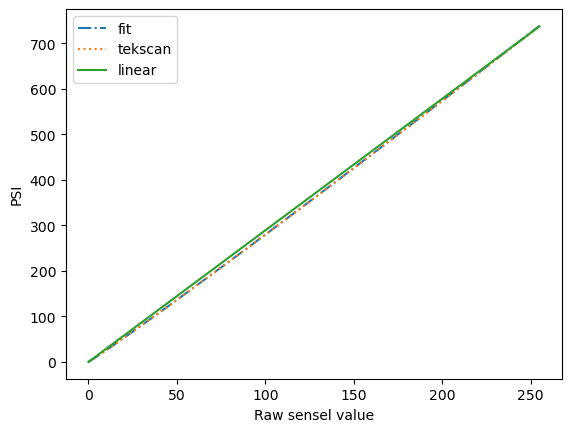

In [149]:
# fit
x = np.linspace(0, 255, 100)
y = a*x**b
plt.plot(x, y, label='fit', linestyle='-.')

# tekscan cal file
x = np.linspace(0, 255, 100)
y = 2.36625*x**1.03604
plt.plot(x, y, label='tekscan', linestyle=':')

# linear but not real linear fit, just for reference
y = (y.max()/x.max()) * x
plt.plot(x, y, label='linear')

plt.xlabel('Raw sensel value')
plt.ylabel('PSI')
plt.legend()

print(f'a: {a:.5f}', f'\nb: {b:.5f}')

#### Trying to figure out calibration file entries

In [114]:
with open(cal_file, 'r') as f:
    for line in f:
        print(line)

VERSION Tekscan Pressure Measurement System 6.03I

HARDWARE 102-K404

MAP_VERSION 6.4

HW_TYPE 3

SENSOR_TYPE 6900

ROWS 28

COLS 28

ROW_SPACING 0.05

COL_SPACING 0.05

SENSEL_AREA 0.0025

NOISE_THRESHOLD 3

SECONDS_PER_FRAME 0.015625

MICRO_SECOND 0

UNITS PSI

SCALE_FACTOR 2.36625

CALIMP1 

CALEQU1 

CALEQR1 

EXPONENT 1.03604

CAL_FPI_1 2.24809

CAL_FPC_1 2.10479

CAL_RSI_1 340

CAL_RSC_1 340

CAL_SM_1 26

CAL_CMO_1 0

CAL_FPI_2 13.4885

CAL_FPC_2 13.2419

CAL_RSI_2 1994

CAL_RSC_2 1994

CAL_SM_2 68

CAL_CMO_2 0

PARALLEL_VOLTAGE_TEST 200

PARALLEL_VOLTAGE_REF 181

VERSA_GAIN 0

CAL_EXP_ENABLED 1

EQUFLAG 1

COLDSPOTFLAG 1



 - CAL_FPI_ - Conversion of input Force to Force pounds 
 - CAL_FPC_ - Maybe the prediction of the total force for the calibration frames? Not sure tho...
 - CAL_RSI_, CAL_RSC_ - sum of raw sensel values for calibration frames
 - CAL_SM_ - Sensel Mask?, equals number of non zero sensels
  
If $F = aR^b$,  
where R is the sum of raw sense values and F is the predicted total force
 - SCALE FACTOR = a
 - EXPONENT = b  

In [236]:
# CAL_FPI_
FP2N = 4.448222 # Force pounds * FP2N = Newtons
print(round(10 / 4.448222, 4))
print(round(60 / 4.448222, 4))

2.2481
13.4885


In [ ]:
# cal5
SF = 2.36625
E = 1.03604
FPC_1 = 2.10479
FPC_2 = 13.2419
RSI_1 = 340
RSI_2 = 1994

psi_1 = SF*RSI_1**E
psi_2 = SF*RSI_2**E
print(FPC_1 / psi_1)
print(FPC_2 / psi_2)

0.0021204826703413574
0.0021342359366592254


In [282]:
# cal6
SF = 0.720167
E = 1.17304
FPC_1 = 1.66312
FPC_2 = 13.1477
RSI_1 = 688
RSI_2 = 3571

psi_1 = SF*RSI_1**E
psi_2 = SF*RSI_2**E
print(FPC_1 / psi_1)
print(FPC_2 / psi_2)

0.0010836414973467998
0.0012412291407758824


In [ ]:
A=0.55*0.55 # sensor area (square inch)
As = A / 121 # per sensel area 
As

# So it fits the power law model to PSI (force pounds / square inch)
# - but why is area 0.0021 not 0.0025?
# - also that's sensel area not total area

0.0025000000000000005

In [313]:
raw60[raw60!=0].shape[0]

68